In [1]:
#Librerias y metodo de lectura

from google.cloud import bigquery
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from datetime import datetime, timedelta
import shap

client = bigquery.Client(project="favorita-aycd")
dataset_ref = bigquery.DatasetReference("favorita-aycd", "PRUEBAS_MCALVACHE")
job_config = bigquery.QueryJobConfig(default_dataset=dataset_ref)

#Metodo consulta
def run_query(query: str):
    query_job = client.query(query, job_config=job_config)
    return query_job.result().to_dataframe()

#Consulta SQL
df=run_query("""SELECT * FROM `CHURN`;""")

c:\Users\PaulF\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Normalizar SEGMENTACION a niveles de valor
df['SEGMENTACION_NIVEL'] = (
    df['SEGMENTACION']
        .astype('string')
        .str.strip()
        .str.upper()
        .map({
            'LA CREME': 'MUY ALTO',
            'HABITUAL PREMIUM': 'ALTO',
            'VALIOSO': 'MEDIO',
            'POTENCIAL': 'MEDIO',
            'OCASIONAL': 'BAJO',
            'MARGINAL': 'MUY BAJO',
            'PERDIDA': 'MUY BAJO'
        })
        .fillna('SIN CLASIFICAR')
)



df.drop(columns=['SEGMENTACION'], inplace=True)
df['SEGMENTACION_NIVEL'].value_counts(dropna=False)

SEGMENTACION_NIVEL
MUY BAJO          573859
MEDIO             299346
BAJO              138591
ALTO               79614
SIN CLASIFICAR     36037
MUY ALTO           20850
Name: count, dtype: int64

In [3]:
sns.set(style="whitegrid")

df_eda = df.copy()

print("Shape del dataset EDA (filas, columnas):", df_eda.shape)

# Lista de columnas que deberían ser numéricas pero pueden ser leídas como 'object'
cols_a_convertir_a_numerico = [
    'GASTO_CLIENTE', 'GASTO_MENSUAL', 'TICKET_PROMEDIO', 'AHORRO',
    'GASTO_ULTS_COMPRAS', 'TICKET_PROMEDIO_ULTS_COMPRAS', 'DELTA_GASTO'
]

print("Convirtiendo columnas a tipo numérico...")
for col in cols_a_convertir_a_numerico:
    if col in df_eda.columns and df_eda[col].dtype == 'object':
        # pd.to_numeric es robusto. errors='coerce' convertirá valores problemáticos en NaN (Nulo)
        df_eda[col] = pd.to_numeric(df_eda[col], errors='coerce')
        print(f"  - Columna '{col}' convertida a numérica.")


print("\nTipos de datos:")
print(df_eda.dtypes)

print("\nPrimeras filas:")
display(df_eda.head())

print("\nPorcentaje de nulos por columna:")
null_pct = df_eda.isna().mean().sort_values(ascending=False) * 100
display(null_pct.to_frame('pct_null'))

num_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df_eda.columns if c not in num_cols]


print("\nColumnas numéricas:")
print(num_cols)
print("\nColumnas categóricas:")
print(cat_cols)

print("\nResumen estadístico de variables numéricas:")
display(df_eda[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

Shape del dataset EDA (filas, columnas): (1148297, 24)
Convirtiendo columnas a tipo numérico...
  - Columna 'GASTO_CLIENTE' convertida a numérica.
  - Columna 'GASTO_MENSUAL' convertida a numérica.
  - Columna 'TICKET_PROMEDIO' convertida a numérica.
  - Columna 'AHORRO' convertida a numérica.
  - Columna 'GASTO_ULTS_COMPRAS' convertida a numérica.
  - Columna 'TICKET_PROMEDIO_ULTS_COMPRAS' convertida a numérica.
  - Columna 'DELTA_GASTO' convertida a numérica.

Tipos de datos:
NUMERODOCUMENTO                  object
GENERO                           object
EDAD                              Int64
AGRUPACION_ESTADO                object
FRECUENCIA                        Int64
FECUENCIA_MENSUAL               float64
GASTO_CLIENTE                   float64
GASTO_MENSUAL                   float64
TICKET_PROMEDIO                 float64
DIAS_ULTIMA_COMPRA                Int64
PRODUCTOS_COMPRADOS               Int64
CATEGORIAS_COMPRADAS              Int64
CHURN                             Int

,NUMERODOCUMENTO,GENERO,EDAD,AGRUPACION_ESTADO,FRECUENCIA,FECUENCIA_MENSUAL,GASTO_CLIENTE,GASTO_MENSUAL,TICKET_PROMEDIO,DIAS_ULTIMA_COMPRA,...,GASTO_ULTS_COMPRAS,FRECUENCIA_ULTS_COMPRAS,TICKET_PROMEDIO_ULTS_COMPRAS,PRODUCTOS_ULTS_COMPRAS,CATEGORIAS_ULTS_COMPRAS,DELTA_GASTO,DELTA_FRECUENCIA,AHORRO,NUM_PROD_DES,SEGMENTACION_NIVEL
0,1719644534,M,57,ACTIVA,619,51.583333,3555.5329,296.294408,5.743995,6,...,4.761425,1.25,3.528212,3.50,2.50,-0.998661,-0.997981,-64.44,25,MUY ALTO
1,1312032624,M,34,ACTIVA,399,33.250000,44913.1605,3742.763375,112.564312,4,...,113.234875,1.00,113.234875,29.25,21.75,-0.997479,-0.997494,-22.44,103,MUY ALTO
2,0911772762,F,59,ACTIVA,374,31.166667,1738.2175,144.851458,4.647640,5,...,3.666775,1.00,3.666775,6.75,6.00,-0.997890,-0.997326,-9.78,20,ALTO
3,1761241726,M,0,ACTIVA,339,28.250000,5310.6441,442.553675,15.665617,4,...,22.138575,1.00,22.138575,12.75,11.75,-0.995831,-0.997050,-2.91,36,MUY ALTO
4,1316291754,F,20,ACTIVA,468,39.000000,3501.5182,291.793183,7.481876,5,...,16.379975,1.50,12.557750,5.75,5.00,-0.995322,-0.996795,-36.33,54,ALTO



Porcentaje de nulos por columna:


,pct_null
DELTA_GASTO,0.021597
NUMERODOCUMENTO,0.000000
EDAD,0.000000
GENERO,0.000000
FRECUENCIA,0.000000
FECUENCIA_MENSUAL,0.000000
GASTO_CLIENTE,0.000000
AGRUPACION_ESTADO,0.000000
GASTO_MENSUAL,0.000000
TICKET_PROMEDIO,0.000000



Columnas numéricas:
['EDAD', 'FRECUENCIA', 'FECUENCIA_MENSUAL', 'GASTO_CLIENTE', 'GASTO_MENSUAL', 'TICKET_PROMEDIO', 'DIAS_ULTIMA_COMPRA', 'PRODUCTOS_COMPRADOS', 'CATEGORIAS_COMPRADAS', 'CHURN', 'DIAS_ENTRE_COMPRAS', 'GASTO_ULTS_COMPRAS', 'FRECUENCIA_ULTS_COMPRAS', 'TICKET_PROMEDIO_ULTS_COMPRAS', 'PRODUCTOS_ULTS_COMPRAS', 'CATEGORIAS_ULTS_COMPRAS', 'DELTA_GASTO', 'DELTA_FRECUENCIA', 'AHORRO', 'NUM_PROD_DES']

Columnas categóricas:
['NUMERODOCUMENTO', 'GENERO', 'AGRUPACION_ESTADO', 'SEGMENTACION_NIVEL']

Resumen estadístico de variables numéricas:


,count,mean,std,min,1%,5%,50%,95%,99%,max
EDAD,1148297.0,41.568636,19.383063,0.0,0.0,0.0,42.0,73.0,82.0,127.0
FRECUENCIA,1148297.0,17.025152,526.383393,1.0,1.0,1.0,7.0,61.0,132.0,563019.0
FECUENCIA_MENSUAL,1148297.0,1.418763,43.865283,0.083333,0.083333,0.083333,0.583333,5.083333,11.0,46918.25
GASTO_CLIENTE,1148297.0,462.588393,4696.385286,-432.9565,1.96,6.5304,157.1144,1825.13922,3675.873488,4915432.1432
GASTO_MENSUAL,1148297.0,38.549033,391.36544,-36.079708,0.163333,0.5442,13.092867,152.094935,306.322791,409619.345267
TICKET_PROMEDIO,1148297.0,31.714598,39.021264,-432.9565,1.64,3.77825,20.244236,95.459438,173.9043,3558.419833
DIAS_ULTIMA_COMPRA,1148297.0,69.509595,83.554747,4.0,4.0,4.0,33.0,265.0,344.0,368.0
PRODUCTOS_COMPRADOS,1148297.0,115.755833,144.535268,1.0,1.0,3.0,59.0,415.0,642.0,17189.0
CATEGORIAS_COMPRADAS,1148297.0,48.205585,41.162402,1.0,1.0,2.0,37.0,129.0,165.0,731.0
CHURN,1148297.0,0.203949,0.402932,0.0,0.0,0.0,0.0,1.0,1.0,1.0


Distribución de GENERO_LIMPIO:


GENERO_LIMPIO
FEMENINO           611079
MASCULINO          494829
NO_ESPECIFICADO     40867
DESCONOCIDO          1522
Name: count, dtype: Int64


Churn por GENERO_LIMPIO:


,conteo,churn_rate
GENERO_LIMPIO,,
FEMENINO,611079,0.20568
MASCULINO,494829,0.200091
NO_ESPECIFICADO,40867,0.223726
DESCONOCIDO,1522,0.231932


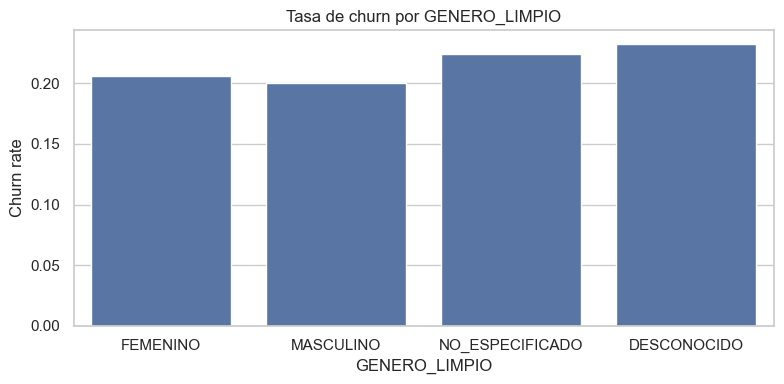

In [4]:
# ==========================================
# 1. Limpieza y EDA de GENERO
# ==========================================

from pandas.api.types import is_numeric_dtype

if 'GENERO' in df_eda.columns:
    genero = df_eda['GENERO'].astype('string').str.strip().str.upper()

    map_genero = {
        'M': 'MASCULINO',
        'F': 'FEMENINO',
        'MASCULINO': 'MASCULINO',
        'FEMENINO': 'FEMENINO'
    }
    genero = genero.replace(map_genero)

    mask_nd = genero.isin(['ND', 'N/D', 'NO DEFINIDO', 'SIN DATO'])
    genero = genero.mask(mask_nd, 'NO_ESPECIFICADO')

    mask_missing = genero.isna() | (genero == '')
    genero = genero.mask(mask_missing, 'DESCONOCIDO')

    df_eda['GENERO_LIMPIO'] = genero

    print("Distribución de GENERO_LIMPIO:")
    display(df_eda['GENERO_LIMPIO'].value_counts(dropna=False))

    if 'CHURN' in df_eda.columns:
        # Intentar usar CHURN como numérica para tasa media
        churn_tmp = df_eda['CHURN']
        if not is_numeric_dtype(churn_tmp):
            try:
                churn_tmp = churn_tmp.astype(int)
            except Exception:
                churn_tmp = None
                print("\nOJO: CHURN no es numérico; revisar niveles antes de calcular tasas.")

        if churn_tmp is not None:
            tmp = (
                df_eda.assign(CHURN_NUM=churn_tmp)
                      .groupby('GENERO_LIMPIO')['CHURN_NUM']
                      .agg(conteo='size', churn_rate='mean')
                      .sort_values('conteo', ascending=False)
            )
            print("\nChurn por GENERO_LIMPIO:")
            display(tmp)

            plt.figure(figsize=(8, 4))
            sns.barplot(x=tmp.index, y=tmp['churn_rate'].values)
            plt.title('Tasa de churn por GENERO_LIMPIO')
            plt.xlabel('GENERO_LIMPIO')
            plt.ylabel('Churn rate')
            plt.tight_layout()
            plt.show()
else:
    print("Columna GENERO no encontrada en df_eda.")

Columnas numéricas a graficar: ['EDAD', 'FRECUENCIA', 'FECUENCIA_MENSUAL', 'GASTO_CLIENTE', 'GASTO_MENSUAL', 'TICKET_PROMEDIO', 'DIAS_ULTIMA_COMPRA', 'PRODUCTOS_COMPRADOS', 'CATEGORIAS_COMPRADAS', 'DIAS_ENTRE_COMPRAS', 'GASTO_ULTS_COMPRAS', 'FRECUENCIA_ULTS_COMPRAS', 'TICKET_PROMEDIO_ULTS_COMPRAS', 'PRODUCTOS_ULTS_COMPRAS', 'CATEGORIAS_ULTS_COMPRAS', 'DELTA_GASTO', 'DELTA_FRECUENCIA', 'AHORRO', 'NUM_PROD_DES']


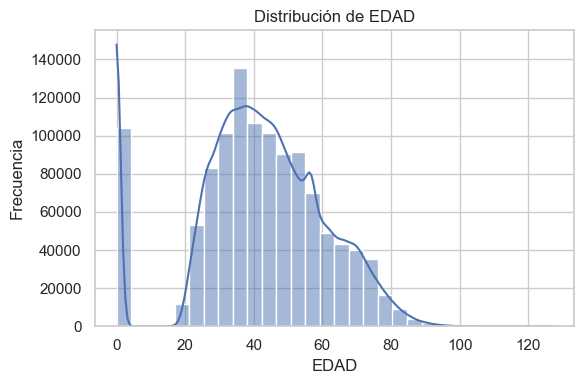

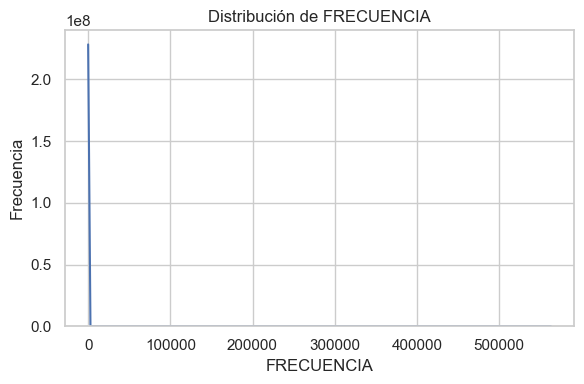

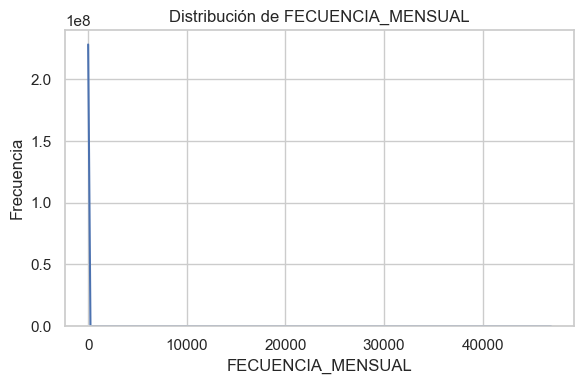

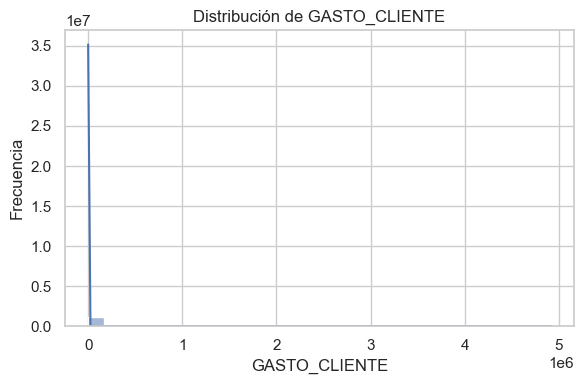

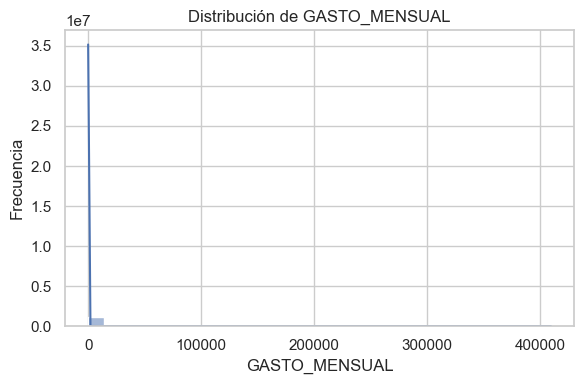

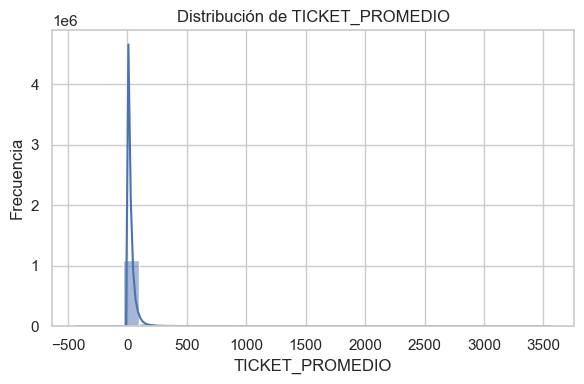

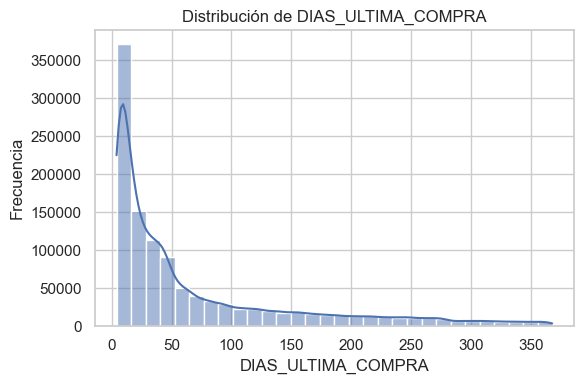

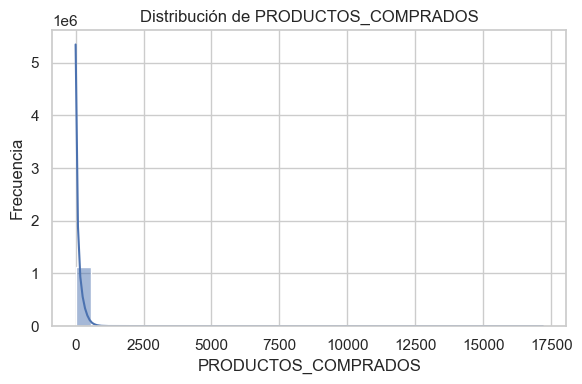

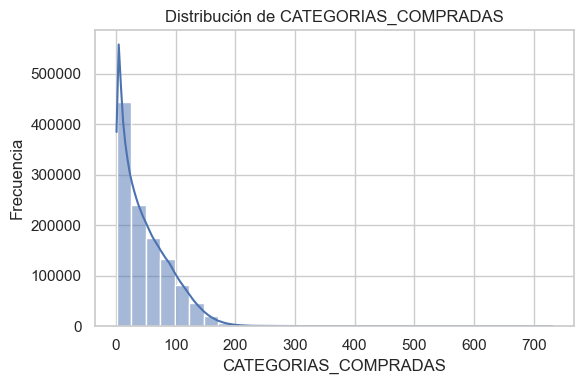

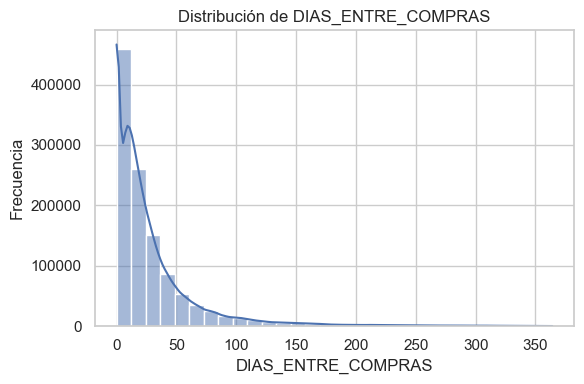

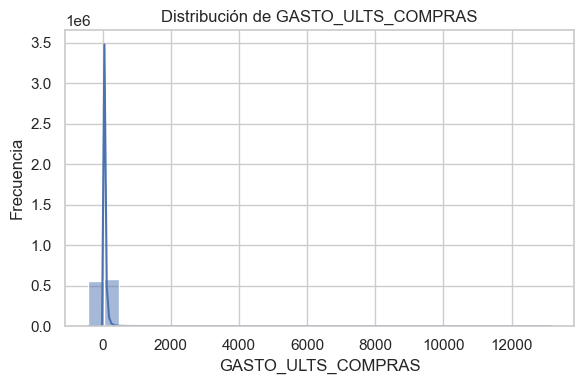

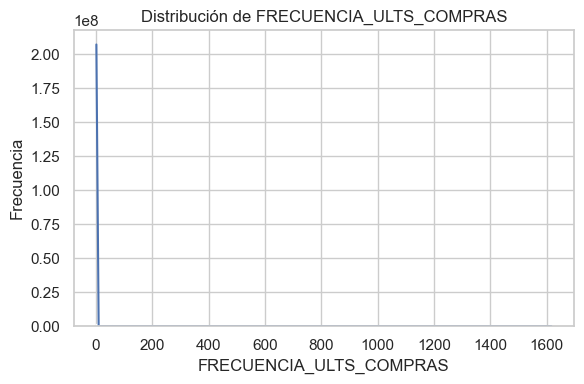

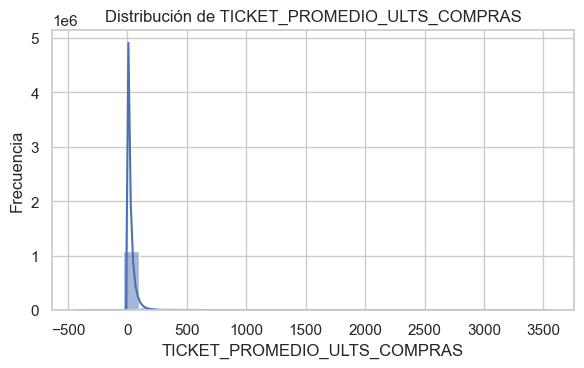

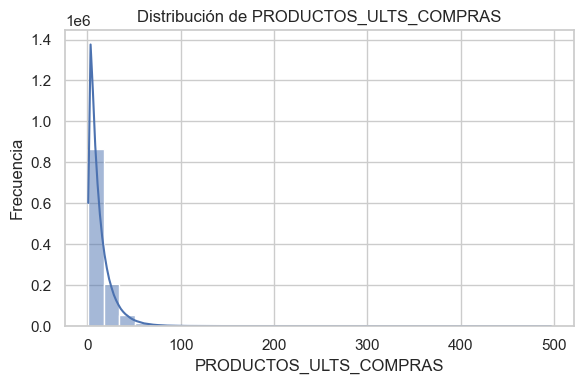

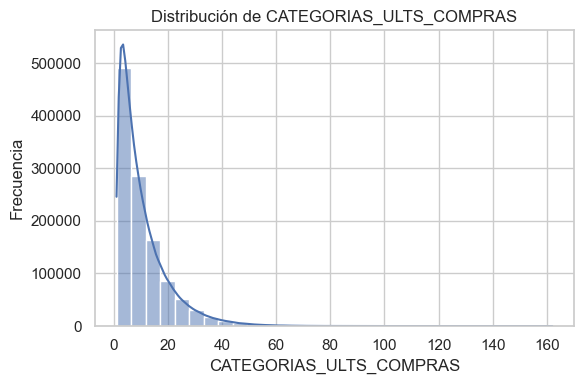

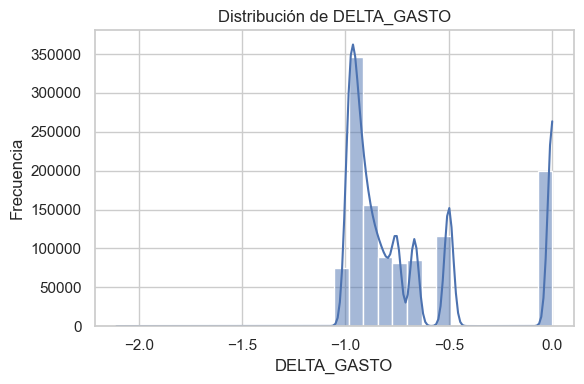

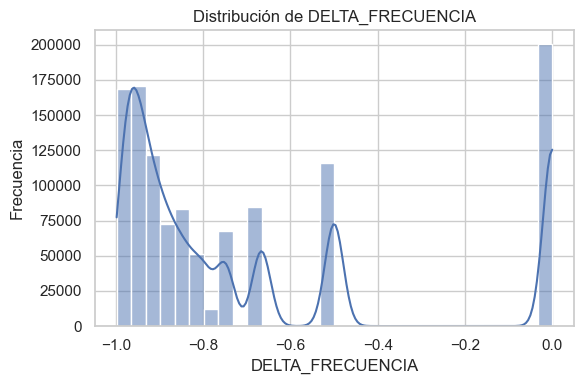

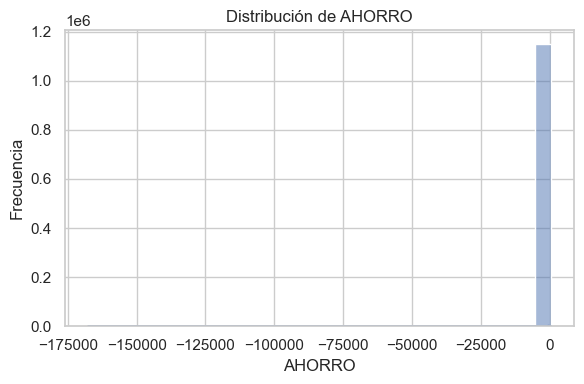

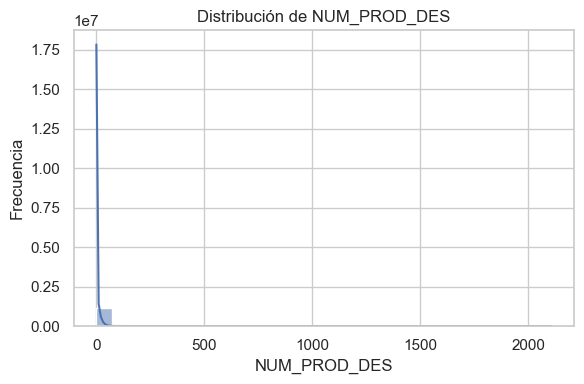

In [5]:
# ==========================================
# 2. Distribuciones de variables numéricas
# ==========================================

num_cols_plot = [
    'EDAD', 'FRECUENCIA', 'FECUENCIA_MENSUAL', 'GASTO_CLIENTE',
    'GASTO_MENSUAL', 'TICKET_PROMEDIO', 'DIAS_ULTIMA_COMPRA',
    'PRODUCTOS_COMPRADOS', 'CATEGORIAS_COMPRADAS', 'DIAS_ENTRE_COMPRAS',
    'GASTO_ULTS_COMPRAS', 'FRECUENCIA_ULTS_COMPRAS',
    'TICKET_PROMEDIO_ULTS_COMPRAS', 'PRODUCTOS_ULTS_COMPRAS',
    'CATEGORIAS_ULTS_COMPRAS', 'DELTA_GASTO', 'DELTA_FRECUENCIA',
    'AHORRO', 'NUM_PROD_DES'
]

num_cols_plot = [c for c in num_cols_plot if c in df_eda.columns]
print("Columnas numéricas a graficar:", num_cols_plot)

for col in num_cols_plot:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_eda[col], kde=True, bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

In [6]:
print("="*50)
print("PASO 5.5: VERIFICACIÓN DE ROBUSTEZ E INTEGRIDAD DE DATOS")
print("="*50)

# --- 1. Definición de Expectativas del Modelo ---
# Estas son las "reglas del juego" que el modelo espera para funcionar correctamente.

# Lista de todas las columnas que el modelo NECESITA para entrenar (features + target).
# Se basa en tu celda de selección de características.
features_requeridas = [
    'EDAD', 'FRECUENCIA', 'FECUENCIA_MENSUAL', 'GASTO_CLIENTE', 'GASTO_MENSUAL',
    'TICKET_PROMEDIO', 'PRODUCTOS_COMPRADOS', 'CATEGORIAS_COMPRADAS', 'DIAS_ENTRE_COMPRAS',
    'GASTO_ULTS_COMPRAS', 'FRECUENCIA_ULTS_COMPRAS', 'TICKET_PROMEDIO_ULTS_COMPRAS',
    'PRODUCTOS_ULTS_COMPRAS', 'CATEGORIAS_ULTS_COMPRAS', 'DELTA_GASTO',
    'DELTA_FRECUENCIA', 'AHORRO', 'NUM_PROD_DES', 'SEGMENTACION_NIVEL', 'GENERO_LIMPIO'
]
TARGET = 'CHURN'
COLUMNAS_ESPERADAS = features_requeridas + [TARGET, 'NUMERODOCUMENTO']

# Tipos de datos esperados para las columnas de features
# Esto previene errores si, por ejemplo, una columna numérica se lee como texto.
DTYPES_ESPERADOS = {
    'EDAD': 'number',
    'FRECUENCIA': 'number',
    'GASTO_CLIENTE': 'number',
    'TICKET_PROMEDIO': 'number',
    'AHORRO': 'number',
    'NUM_PROD_DES': 'number',
    'SEGMENTACION_NIVEL': 'object', # Categórica
    'GENERO_LIMPIO': 'string'      # Categórica
}


# --- 2. Función de Verificación ---
def verificar_integridad_dataframe(df: pd.DataFrame, columnas_esperadas: list, dtypes_esperados: dict, target: str):
    """
    Función que realiza un chequeo completo sobre el DataFrame antes de entrar al pipeline.
    Si algo falla, lanza un error claro para detener la ejecución.
    """
    print("Iniciando verificación de integridad de datos...")
    errores = []

    # Verificación 1: ¿Están todas las columnas necesarias?
    columnas_actuales = set(df.columns)
    columnas_faltantes = set(columnas_esperadas) - columnas_actuales
    if columnas_faltantes:
        errores.append(f"ERROR: Faltan columnas esenciales en el DataFrame: {list(columnas_faltantes)}")

    # Verificación 2: ¿Hay columnas inesperadas que podrían indicar un problema?
    columnas_inesperadas = columnas_actuales - set(columnas_esperadas)
    if columnas_inesperadas:
        print(f"ADVERTENCIA: Se encontraron columnas no esperadas por el modelo: {list(columnas_inesperadas)}. Serán ignoradas, pero se recomienda revisar.")

    # Verificación 3: ¿Los tipos de datos (dtypes) son correctos?
    for col, dtype_esperado in dtypes_esperados.items():
        if col in df.columns:
            if dtype_esperado == 'number' and not pd.api.types.is_numeric_dtype(df[col]):
                errores.append(f"ERROR de Dtype: La columna '{col}' debería ser numérica, pero es de tipo {df[col].dtype}.")
            elif dtype_esperado == 'object' and not pd.api.types.is_object_dtype(df[col]) and not pd.api.types.is_categorical_dtype(df[col]):
                errores.append(f"ERROR de Dtype: La columna '{col}' debería ser categórica (object), pero es de tipo {df[col].dtype}.")

    # Verificación 4: ¿Hay valores nulos en la variable objetivo?
    if target in df.columns and df[target].isnull().any():
        errores.append(f"ERROR: La columna objetivo '{target}' contiene valores nulos. El modelo no puede entrenar o evaluar con un target nulo.")

    # Verificación 5: ¿La variable objetivo es binaria?
    if target in df.columns and df[target].nunique() != 2:
         errores.append(f"ERROR: La columna objetivo '{target}' no es binaria. Contiene {df[target].nunique()} valores únicos.")

    # --- Resumen de la Verificación ---
    if errores:
        print("\n¡VERIFICACIÓN FALLIDA! Se encontraron los siguientes problemas críticos:")
        for error in errores:
            print(f"  - {error}")
        # Detener la ejecución del notebook lanzando una excepción
        raise ValueError("La integridad de los datos no cumple con los requisitos para el modelado. Revisa los errores listados.")
    else:
        print("\n¡Verificación de integridad completada exitosamente! Los datos están listos para el modelado.")

# --- 3. Ejecutar la Verificación ---
try:
    verificar_integridad_dataframe(
        df=df_eda,
        columnas_esperadas=COLUMNAS_ESPERADAS,
        dtypes_esperados=DTYPES_ESPERADOS,
        target=TARGET
    )
except ValueError as e:
    print(f"\nProceso detenido debido a: {e}")

PASO 5.5: VERIFICACIÓN DE ROBUSTEZ E INTEGRIDAD DE DATOS
Iniciando verificación de integridad de datos...
ADVERTENCIA: Se encontraron columnas no esperadas por el modelo: ['DIAS_ULTIMA_COMPRA', 'AGRUPACION_ESTADO', 'GENERO']. Serán ignoradas, pero se recomienda revisar.

¡Verificación de integridad completada exitosamente! Los datos están listos para el modelado.


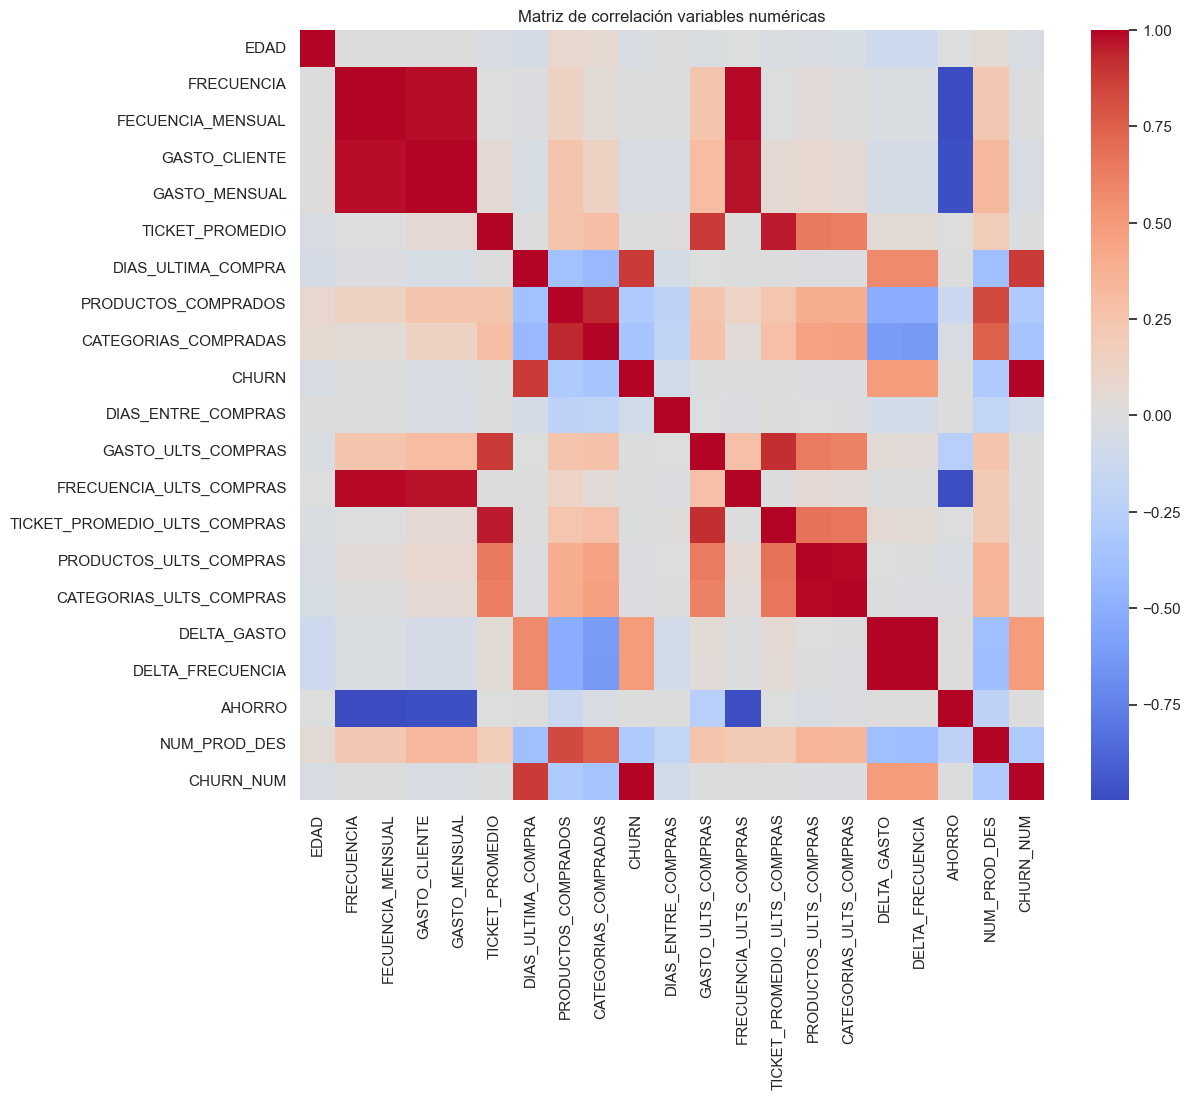

Correlación de variables numéricas con CHURN_NUM:


,corr_con_churn
CHURN,1.000000
CHURN_NUM,1.000000
DIAS_ULTIMA_COMPRA,0.878052
DELTA_FRECUENCIA,0.487981
DELTA_GASTO,0.487128
AHORRO,0.006165
TICKET_PROMEDIO_ULTS_COMPRAS,-0.006583
FRECUENCIA_ULTS_COMPRAS,-0.007543
TICKET_PROMEDIO,-0.008299
FECUENCIA_MENSUAL,-0.013345


In [7]:
# ==========================================
# 3. Correlaciones numéricas y relación con CHURN
# ==========================================

from pandas.api.types import is_numeric_dtype

churn_col = 'CHURN'
churn_numeric = None

if churn_col in df_eda.columns:
    if is_numeric_dtype(df_eda[churn_col]):
        churn_numeric = df_eda[churn_col]
    else:
        # Intentar conversión genérica a int
        try:
            churn_numeric = df_eda[churn_col].astype(int)
        except Exception:
            print("OJO: CHURN no se pudo convertir a numérica. Revisar niveles.")
else:
    print("Columna CHURN no encontrada en df_eda.")

num_cols_corr = df_eda.select_dtypes(include=[np.number]).columns.tolist()

if churn_numeric is not None and 'CHURN_NUM' not in df_eda.columns:
    df_eda['CHURN_NUM'] = churn_numeric
    if 'CHURN_NUM' not in num_cols_corr:
        num_cols_corr = num_cols_corr + ['CHURN_NUM']

if num_cols_corr:
    corr = df_eda[num_cols_corr].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Matriz de correlación variables numéricas')
    plt.show()

    if 'CHURN_NUM' in corr.columns:
        corr_target = corr['CHURN_NUM'].sort_values(ascending=False)
        print("Correlación de variables numéricas con CHURN_NUM:")
        display(corr_target.to_frame('corr_con_churn'))
else:
    print("No se encontraron columnas numéricas para correlación.")

Churn medio global: 0.2039

==== GENERO_LIMPIO ====


,conteo,churn_rate
GENERO_LIMPIO,,
FEMENINO,611079,0.20568
MASCULINO,494829,0.200091
NO_ESPECIFICADO,40867,0.223726
DESCONOCIDO,1522,0.231932


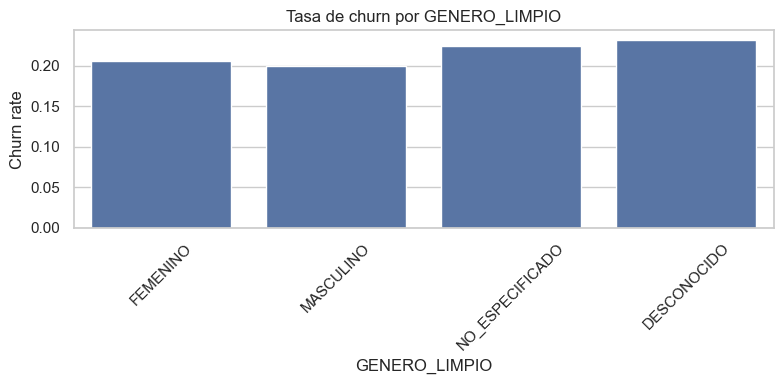


==== AGRUPACION_ESTADO ====


,conteo,churn_rate
AGRUPACION_ESTADO,,
ACTIVA,1144600,0.20356
NUEVA,1848,0.320346
CANCELADA,1792,0.323103
NO DISPONIBLE,47,0.468085
SUSPENDIDA,7,0.428571
VIRTUAL,2,1.0
OLVIDADA,1,1.0


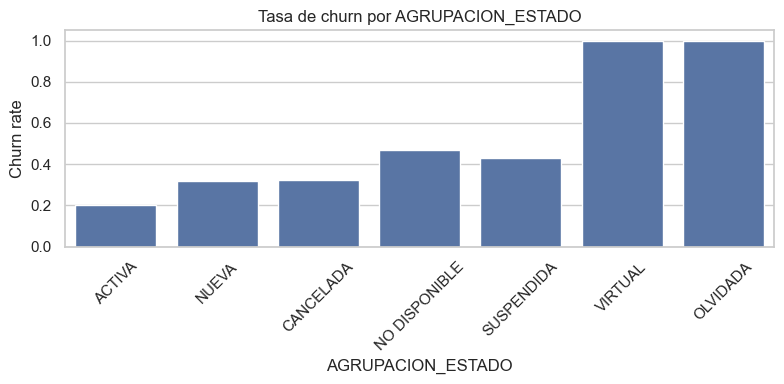


==== SEGMENTACION_NIVEL ====


,conteo,churn_rate
SEGMENTACION_NIVEL,,
MUY BAJO,573859,0.325218
MEDIO,299346,0.007196
BAJO,138591,0.192733
ALTO,79614,0.002449
SIN CLASIFICAR,36037,0.512779
MUY ALTO,20850,0.001247


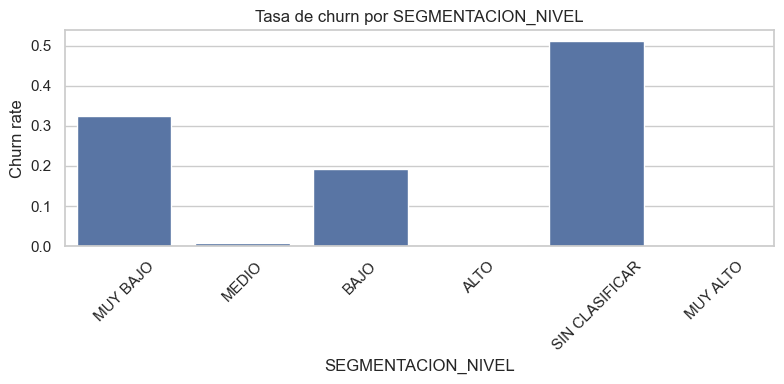


==== EDAD_BIN ====


C:\Users\PaulF\AppData\Local\Temp\ipykernel_15636\1836607708.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_eda.groupby('EDAD_BIN')[churn_for_group]


,conteo,churn_rate
EDAD_BIN,,
36-45,265393,0.198751
26-35,238271,0.224337
46-55,206982,0.189978
<=25,168935,0.23705
56-65,140117,0.19321
65+,128597,0.167601


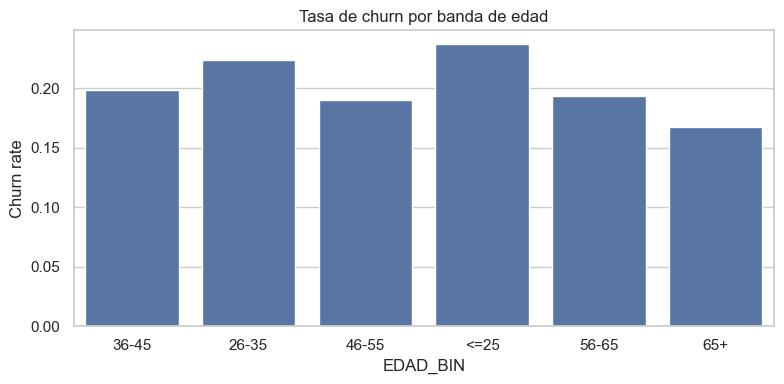

In [8]:
# ==========================================
# 4. Churn por segmentos clave (categóricas)
# ==========================================

from pandas.api.types import is_numeric_dtype

if 'CHURN_NUM' in df_eda.columns:
    churn_for_group = 'CHURN_NUM'
elif 'CHURN' in df_eda.columns and is_numeric_dtype(df_eda['CHURN']):
    churn_for_group = 'CHURN'
else:
    churn_for_group = None
    print("OJO: No hay columna de churn numérica para agrupar.")

cat_to_check = []
for col in ['GENERO_LIMPIO', 'AGRUPACION_ESTADO', 'SEGMENTACION_NIVEL']:
    if col in df_eda.columns:
        cat_to_check.append(col)

if churn_for_group is not None:
    print(f"Churn medio global: {df_eda[churn_for_group].mean():.4f}")

    for col in cat_to_check:
        print(f"\n==== {col} ====")
        tmp = (
            df_eda.groupby(col)[churn_for_group]
                  .agg(conteo='size', churn_rate='mean')
                  .sort_values('conteo', ascending=False)
        )
        display(tmp)

        plt.figure(figsize=(8, 4))
        sns.barplot(x=tmp.index, y=tmp['churn_rate'].values)
        plt.title(f'Tasa de churn por {col}')
        plt.xlabel(col)
        plt.ylabel('Churn rate')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # EDAD: churn por bandas de edad
    if 'EDAD' in df_eda.columns:
        df_eda['EDAD_BIN'] = pd.cut(df_eda['EDAD'], bins=[0, 25, 35, 45, 55, 65, 120],
                                     labels=['<=25', '26-35', '36-45', '46-55', '56-65', '65+'],
                                     include_lowest=True)
        print("\n==== EDAD_BIN ====")
        tmp_age = (
            df_eda.groupby('EDAD_BIN')[churn_for_group]
                  .agg(conteo='size', churn_rate='mean')
                  .sort_values('conteo', ascending=False)
        )
        display(tmp_age)

        plt.figure(figsize=(8, 4))
        sns.barplot(x=tmp_age.index.astype(str), y=tmp_age['churn_rate'].values)
        plt.title('Tasa de churn por banda de edad')
        plt.xlabel('EDAD_BIN')
        plt.ylabel('Churn rate')
        plt.tight_layout()
        plt.show()
else:
    print("No se puede calcular churn por segmentos sin churn numérico.")

In [9]:
# ==========================================
# 5. "Correlación" entre categóricas y CHURN (Cramér's V)
# ==========================================

from pandas.api.types import is_numeric_dtype
from math import sqrt

# Asegurarnos de tener una columna de churn numérica
if 'CHURN_NUM' in df_eda.columns:
    churn_cat = 'CHURN_NUM'
elif 'CHURN' in df_eda.columns and is_numeric_dtype(df_eda['CHURN']):
    churn_cat = 'CHURN'
else:
    # Intentar conversión a int
    try:
        df_eda['CHURN_NUM'] = df_eda['CHURN'].astype(int)
        churn_cat = 'CHURN_NUM'
    except Exception:
        churn_cat = None
        print("No se pudo obtener CHURN como variable binaria numérica para análisis categórico.")

# Función Cramér's V usando chi-cuadrado (sin depender de scipy)
def cramers_v(confusion_matrix: pd.DataFrame) -> float:
    chi2 = 0.0
    n = confusion_matrix.to_numpy().sum()
    row_sums = confusion_matrix.sum(axis=1).to_numpy()
    col_sums = confusion_matrix.sum(axis=0).to_numpy()

    expected = np.outer(row_sums, col_sums) / n
    observed = confusion_matrix.to_numpy()
    # Evitar divisiones por cero
    mask = expected > 0
    chi2 = (((observed - expected) ** 2) / expected)[mask].sum()

    r, k = observed.shape
    return np.sqrt(chi2 / (n * (min(k - 1, r - 1))))

if churn_cat is not None:
    cat_for_corr = [c for c in df_eda.columns if c not in num_cols and c != churn_cat]

    results = []
    for col in cat_for_corr:
        # Evitar demasiados niveles (solo para tablas manejables)
        if df_eda[col].nunique(dropna=False) > 50:
            continue
        ct = pd.crosstab(df_eda[col], df_eda[churn_cat])
        v = cramers_v(ct)
        results.append((col, v, df_eda[col].nunique()))

    if results:
        df_cramers = pd.DataFrame(results, columns=['variable', 'cramers_v', 'n_levels'])
        df_cramers = df_cramers.sort_values('cramers_v', ascending=False)
        print("Cramér's V entre variables categóricas y CHURN (0 = sin relación, 1 = muy fuerte):")
        display(df_cramers)
    else:
        print("No se encontraron variables categóricas adecuadas para calcular Cramér's V.")
else:
    print("No se puede calcular Cramér's V sin una variable CHURN binaria numérica.")

Cramér's V entre variables categóricas y CHURN (0 = sin relación, 1 = muy fuerte):


,variable,cramers_v,n_levels
2,SEGMENTACION_NIVEL,0.384564,6
4,EDAD_BIN,0.052700,6
1,AGRUPACION_ESTADO,0.017360,7
0,GENERO,0.011893,4
3,GENERO_LIMPIO,0.011893,4


In [10]:
# ===================================================================
# 6: Partición Estratificada de Conjuntos
# ===================================================================

from sklearn.model_selection import train_test_split

#Eliminar CHURN_NUM que es una columna auxiliar creada para análisis, pero no debe usarse en modelado.
if 'CHURN_NUM' in df_eda.columns:
    df_eda.drop(columns=['CHURN_NUM'], inplace=True)
    print("Columna auxiliar 'CHURN_NUM' eliminada del DataFrame para modelado.")


churn_col = df_eda.copy()
print("="*50)
print("PARTICIÓN DE CONJUNTOS")
print("="*50)


# --- 1. Definir constantes para las columnas clave ---
ID_COLUMN = 'NUMERODOCUMENTO'
TARGET_COLUMN = 'CHURN'
cols_a_excluir = [
    # Columnas de Fuga (Leakage) o Proxies
    'CHURN_NUM',              # Copia del target
    'AGRUPACION_ESTADO',      # Causante de overfitting
    'DIAS_ULTIMA_COMPRA',     # Nace de la teoria de churn
    
    # Columnas Redundantes o Derivadas del EDA
    'GENERO',                 # Usaremos GENERO_LIMPIO en su lugar si es necesario
    'EDAD_BIN',               # Creada en EDA, no debe ser una feature si el modelo ve EDAD
    'SEGMENTACION',           # Usamos SEGMENTACION_NIVEL
]

# Obtenemos la lista de todas las columnas disponibles en el df_eda
all_cols = df_eda.columns.tolist()

# Las features serán TODAS las columnas MENOS el ID, el Target y nuestra lista de exclusión.
features_to_use = [
    col for col in all_cols
    if col not in [ID_COLUMN, TARGET_COLUMN] + cols_a_excluir
]

print("--- Selección de Características para el Modelo (Versión Estricta) ---")
print(f"Se usarán {len(features_to_use)} features.")
print("\nColumnas en la lista de exclusión:")
print(cols_a_excluir)
print("\nFeatures finales que entrarán al modelo:")
print(features_to_use)


# --- 3. Preparar los datos para la división: X (features) y y (target) ---
y = df_eda[TARGET_COLUMN]
X = df_eda[features_to_use] # Usamos nuestra lista de features súper curada

print(f"\nDefinidas las características (X) con shape: {X.shape}")
print(f"Definida la variable objetivo (y) con shape: {y.shape}")


# --- 4. Primera División: Entrenamiento (70%) vs. Temporal (30%) ---
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# --- 5. Segunda División: Validación (15%) vs. Prueba (15%) ---
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# --- 6. Verificación Final de los Resultados ---
print("\n--- Tamaños de los conjuntos generados ---")
print(f"Conjunto de Entrenamiento (X_train): {X_train.shape}")
print(f"Conjunto de Validación (X_val):    {X_val.shape}")
print(f"Conjunto de Prueba (X_test):       {X_test.shape}")

Columna auxiliar 'CHURN_NUM' eliminada del DataFrame para modelado.
PARTICIÓN DE CONJUNTOS
--- Selección de Características para el Modelo (Versión Estricta) ---
Se usarán 20 features.

Columnas en la lista de exclusión:
['CHURN_NUM', 'AGRUPACION_ESTADO', 'DIAS_ULTIMA_COMPRA', 'GENERO', 'EDAD_BIN', 'SEGMENTACION']

Features finales que entrarán al modelo:
['EDAD', 'FRECUENCIA', 'FECUENCIA_MENSUAL', 'GASTO_CLIENTE', 'GASTO_MENSUAL', 'TICKET_PROMEDIO', 'PRODUCTOS_COMPRADOS', 'CATEGORIAS_COMPRADAS', 'DIAS_ENTRE_COMPRAS', 'GASTO_ULTS_COMPRAS', 'FRECUENCIA_ULTS_COMPRAS', 'TICKET_PROMEDIO_ULTS_COMPRAS', 'PRODUCTOS_ULTS_COMPRAS', 'CATEGORIAS_ULTS_COMPRAS', 'DELTA_GASTO', 'DELTA_FRECUENCIA', 'AHORRO', 'NUM_PROD_DES', 'SEGMENTACION_NIVEL', 'GENERO_LIMPIO']

Definidas las características (X) con shape: (1148297, 20)
Definida la variable objetivo (y) con shape: (1148297,)

--- Tamaños de los conjuntos generados ---
Conjunto de Entrenamiento (X_train): (803807, 20)
Conjunto de Validación (X_val): 

In [11]:
# ===================================================================
# 7:  Pipeline de Preprocesamiento y Definición del Modelo Híbrido
# ===================================================================
print("PASO PREPROCESAMIENTO Y DEFINICIÓN DEL MODELO AVANZADO")

# Separamos las columnas numéricas y categóricas de X_train
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print(f"Columnas numéricas a imputar y escalar ({len(numeric_features)}): {numeric_features}")
print(f"Columnas categóricas a imputar y codificar ({len(categorical_features)}): {categorical_features}")

# --- Pipeline para variables numéricas ---
# PASO 1: Imputar (rellenar) los NaNs con la mediana.
# PASO 2: Escalar los datos.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# --- Pipeline para variables categóricas ---
# PASO 1: Imputar los NaNs con el valor más frecuente.
# PASO 2: Codificar con One-Hot Encoding.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# --- Combinar ambos pipelines en un único objeto preprocesador ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

# --- Definir el Modelo Híbrido Propuesto (Stacking) ---
print("\n--- Definiendo el modelo híbrido (Stacking) ---")

count_neg = y_train.value_counts()[0]
count_pos = y_train.value_counts()[1]
scale_pos_weight_value = count_neg / count_pos

estimators = [
    ('rf', RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=150, scale_pos_weight=scale_pos_weight_value, use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1))
]

meta_model = LogisticRegression(solver='liblinear')

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    cv=3,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=True
)

# --- Ensamblar el Pipeline Final ---
pipeline_hibrido = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', stacking_model)
])

print("\nPipeline con imputación y modelo híbrido creados exitosamente.")
print("El pipeline está listo para ser entrenado.")
display(pipeline_hibrido)


PASO PREPROCESAMIENTO Y DEFINICIÓN DEL MODELO AVANZADO
Columnas numéricas a imputar y escalar (18): ['EDAD', 'FRECUENCIA', 'FECUENCIA_MENSUAL', 'GASTO_CLIENTE', 'GASTO_MENSUAL', 'TICKET_PROMEDIO', 'PRODUCTOS_COMPRADOS', 'CATEGORIAS_COMPRADAS', 'DIAS_ENTRE_COMPRAS', 'GASTO_ULTS_COMPRAS', 'FRECUENCIA_ULTS_COMPRAS', 'TICKET_PROMEDIO_ULTS_COMPRAS', 'PRODUCTOS_ULTS_COMPRAS', 'CATEGORIAS_ULTS_COMPRAS', 'DELTA_GASTO', 'DELTA_FRECUENCIA', 'AHORRO', 'NUM_PROD_DES']
Columnas categóricas a imputar y codificar (2): ['SEGMENTACION_NIVEL', 'GENERO_LIMPIO']

--- Definiendo el modelo híbrido (Stacking) ---

Pipeline con imputación y modelo híbrido creados exitosamente.
El pipeline está listo para ser entrenado.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

print("="*60)
print("INICIANDO VALIDACIÓN DE ESTABILIDAD ")
print("="*60)

# --- CAMBIO 1: Reducimos el número de pliegues a 5 ---
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_para_cv = X 
y_para_cv = y

scoring_metrics = ['roc_auc', 'recall', 'precision', 'f1_weighted']
cv_results = {}

# --- CAMBIO 2: Usamos n_jobs=1 para evitar el colapso de memoria ---
print(f"Evaluando el pipeline con 5-Fold Cross-Validation y n_jobs=1 (más lento pero más seguro)...")

for metric in scoring_metrics:
    print(f"\nCalculando métrica: {metric}...")
    # Usamos n_jobs=1 para forzar la ejecución secuencial
    scores = cross_val_score(pipeline_hibrido, X_para_cv, y_para_cv, cv=cv_strategy, scoring=metric, n_jobs=1)
    cv_results[metric] = scores
    print(f"Resultados para {metric} en cada uno de los 5 pliegues: \n{np.round(scores, 4)}")
    print(f" -> Media: {np.mean(scores):.4f}")
    print(f" -> Desviación Estándar: {np.std(scores):.4f}")

# --- (El resto del código para la tabla es igual) ---
print("\n" + "="*60)
print("TABLA RESUMEN DE ESTABILIDAD DEL MODELO (PARA LA TESIS)")
print("="*60)
# (El código de la tabla se mantiene sin cambios)
print("| Métrica         | Media (Promedio) | Desviación Estándar (Variabilidad) |")
print("|-----------------|------------------|------------------------------------|")
for metric, scores in cv_results.items():
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    metric_name = metric.replace('_', ' ').replace('roc auc', 'AUC').title()
    print(f"| {metric_name:<15} | {mean_score:.4f} | {std_score:.4f} |")
print("="*60)

INICIANDO VALIDACIÓN DE ESTABILIDAD 
Evaluando el pipeline con 5-Fold Cross-Validation y n_jobs=1 (más lento pero más seguro)...

Calculando métrica: roc_auc...
Resultados para roc_auc en cada uno de los 5 pliegues: 
[0.9351 0.9356 0.9347 0.935  0.9354]
 -> Media: 0.9352
 -> Desviación Estándar: 0.0003

Calculando métrica: recall...
Resultados para recall en cada uno de los 5 pliegues: 
[0.7857 0.7843 0.7827 0.7833 0.7825]
 -> Media: 0.7837
 -> Desviación Estándar: 0.0012

Calculando métrica: precision...
Resultados para precision en cada uno de los 5 pliegues: 
[0.6592 0.6604 0.6603 0.6605 0.6608]
 -> Media: 0.6602
 -> Desviación Estándar: 0.0005

Calculando métrica: f1_weighted...
Resultados para f1_weighted en cada uno de los 5 pliegues: 
[0.8774 0.8776 0.8774 0.8775 0.8775]
 -> Media: 0.8775
 -> Desviación Estándar: 0.0001

TABLA RESUMEN DE ESTABILIDAD DEL MODELO (PARA LA TESIS)
| Métrica         | Media (Promedio) | Desviación Estándar (Variabilidad) |
|-----------------|---------

 ENTRENAMIENTO Y EVALUACIÓN DEL MODELO PROPUESTO
Iniciando el entrenamiento del modelo híbrido...

¡Entrenamiento completado en 505.66 segundos!


--- Evaluación del Modelo Híbrido en el Conjunto de Prueba ---

--- Reporte de Clasificación ---
Analiza el 'recall' y 'f1-score' para la clase 1, son las métricas más importantes aquí.
              precision    recall  f1-score   support

         0.0       0.94      0.90      0.92    137116
         1.0       0.66      0.78      0.72     35129

    accuracy                           0.87    172245
   macro avg       0.80      0.84      0.82    172245
weighted avg       0.88      0.87      0.88    172245


Área Bajo la Curva ROC (AUC-ROC): 0.9353

--- Matriz de Confusión ---
Muestra los Verdaderos Positivos, Falsos Positivos, etc.


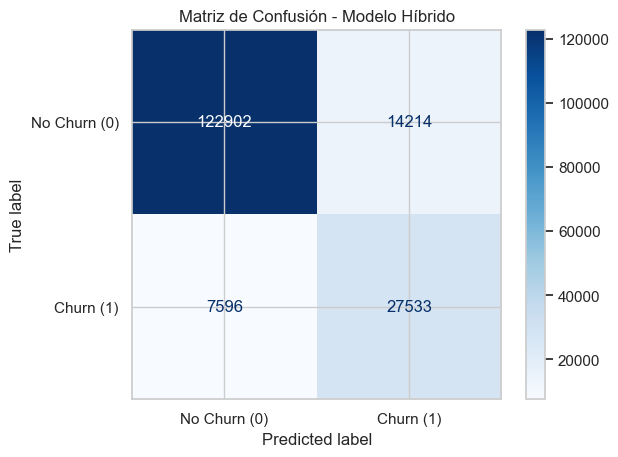


--- Curva ROC ---


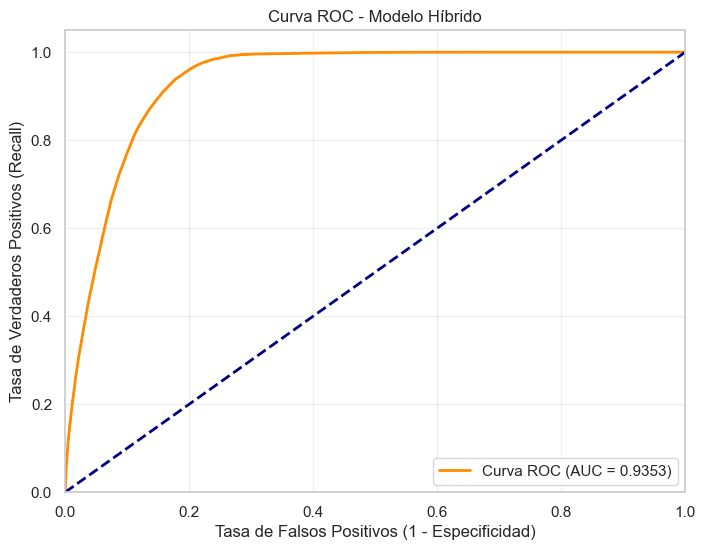

In [12]:
# ===================================================================
# Celda 8: Entrenamiento y Evaluación del Modelo Híbrido
# ===================================================================
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import time

print("="*50)
print(" ENTRENAMIENTO Y EVALUACIÓN DEL MODELO PROPUESTO")
print("="*50)

# --- 1. Entrenamiento del Pipeline Completo ---
# Usamos el pipeline que definimos en la celda anterior.
# El método .fit() entrenará primero el preprocesador con X_train
# y luego entrenará el modelo híbrido con los datos ya preprocesados.
print("Iniciando el entrenamiento del modelo híbrido...")

start_time = time.time()
pipeline_hibrido.fit(X_train, y_train)
end_time = time.time()

training_time = end_time - start_time
print(f"\n¡Entrenamiento completado en {training_time:.2f} segundos!")


# --- 2. Evaluación del Modelo en el Conjunto de Prueba (Test Set) ---
# Ahora usamos el pipeline entrenado para hacer predicciones en datos que nunca ha visto.
print("\n\n--- Evaluación del Modelo Híbrido en el Conjunto de Prueba ---")
y_pred_hibrido = pipeline_hibrido.predict(X_test)
y_proba_hibrido = pipeline_hibrido.predict_proba(X_test)[:, 1] # Probabilidades para la clase '1' (Churn)

# --- 3. Reporte de Métricas de Clasificación ---
# Este reporte es el resumen principal del rendimiento del modelo.
print("\n--- Reporte de Clasificación ---")
print("Analiza el 'recall' y 'f1-score' para la clase 1, son las métricas más importantes aquí.")
reporte = classification_report(y_test, y_pred_hibrido)
print(reporte)

# --- 4. Métrica Clave Adicional: AUC-ROC ---
# El AUC-ROC mide la capacidad del modelo para distinguir entre clases.
# Un valor cercano a 1.0 es excelente. Un valor de 0.5 es un modelo al azar.
auc_score = roc_auc_score(y_test, y_proba_hibrido)
print(f"\nÁrea Bajo la Curva ROC (AUC-ROC): {auc_score:.4f}")

# --- 5. Visualización de Resultados ---

# Matriz de Confusión: ¿Cuántos aciertos y errores hubo por clase?
print("\n--- Matriz de Confusión ---")
print("Muestra los Verdaderos Positivos, Falsos Positivos, etc.")
ConfusionMatrixDisplay.from_estimator(pipeline_hibrido, X_test, y_test,
                                      display_labels=['No Churn (0)', 'Churn (1)'],
                                      cmap='Blues',
                                      normalize=None) # 'true' para ver porcentajes
plt.title('Matriz de Confusión - Modelo Híbrido')
plt.show()


# Curva ROC: Visualiza el trade-off entre la tasa de verdaderos positivos y falsos positivos.
print("\n--- Curva ROC ---")
fpr, tpr, _ = roc_curve(y_test, y_proba_hibrido)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC - Modelo Híbrido')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# ===================================================================
# Celda 9: Optimización de Hiperparámetros (Versión Ligera)
# ===================================================================
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

print("="*50)
print("PASO OPTIMIZACIÓN DE HIPERPARÁMETROS (VERSIÓN LIGERA)")
print("="*50)

# --- 1. Definir un "Menú" de Hiperparámetros MÁS REDUCIDO ---

param_dist_light = {
    # --- Parámetros para RandomForest ('rf') ---
    # Rango más pequeño para el número de árboles
    'classifier__rf__n_estimators': randint(100, 250), 
    'classifier__rf__max_depth': [10, 20, None], 
    'classifier__rf__min_samples_split': randint(2, 8),
    'classifier__rf__min_samples_leaf': randint(1, 8),

    # --- Parámetros para XGBoost ('xgb') ---
    # Rango más pequeño para el número de árboles
    'classifier__xgb__n_estimators': randint(100, 250),
    'classifier__xgb__max_depth': randint(3, 8), # Profundidad máxima reducida
    'classifier__xgb__learning_rate': uniform(0.01, 0.15),
    'classifier__xgb__subsample': uniform(0.7, 0.3),
    'classifier__xgb__colsample_bytree': uniform(0.7, 0.3),
    
    # --- Parámetros para el Metamodelo ---
    'classifier__final_estimator__C': uniform(0.1, 5) # Rango de C reducido
}

# --- 2. Configurar la Búsqueda Aleatoria con menos carga ---
random_search_light = RandomizedSearchCV(
    estimator=pipeline_hibrido,
    param_distributions=param_dist_light,
    n_iter=10, #
    cv=3,
    scoring='f1_weighted',
    verbose=2,
    random_state=42,
    n_jobs=4, 
    refit=True
)

print("Iniciando la búsqueda de hiperparámetros (versión ligera)...")
print(f"Se probarán {random_search_light.n_iter} combinaciones diferentes con {random_search_light.n_jobs} procesos en paralelo.")

# --- 3. Ejecutar la Búsqueda ---
start_time_search = time.time()
random_search_light.fit(X_train, y_train)
end_time_search = time.time()

search_time = end_time_search - start_time_search
print(f"\nBúsqueda completada en {search_time / 60:.2f} minutos.")


# --- 4. Mostrar los Resultados de la Optimización ---
print("\n\n--- Resultados de la Optimización (Ligera) ---")
print("Mejor puntuación (f1_weighted) encontrada en validación cruzada:")
print(f"{random_search_light.best_score_:.4f}")

print("\nMejores hiperparámetros encontrados:")
best_params_light = random_search_light.best_params_
for param, value in best_params_light.items():
    print(f"  - {param}: {value}")

# Guardamos el mejor modelo encontrado para la siguiente celda
modelo_optimizado = random_search_light.best_estimator_


In [ ]:
# ===================================================================
# Celda 10: Evaluación del Modelo OPTIMIZADO
# ===================================================================

print("="*50)
print("PASO EVALUACIÓN DEL MODELO FINAL OPTIMIZADO")
print("="*50)

# --- Evaluación en el Conjunto de Prueba usando el modelo optimizado ---
print("\n--- Evaluación del Modelo OPTIMIZADO en el Conjunto de Prueba ---")
y_pred_opt = modelo_optimizado.predict(X_test)
y_proba_opt = modelo_optimizado.predict_proba(X_test)[:, 1]

# --- Reporte de Clasificación ---
print("\n--- Reporte de Clasificación (Optimizado) ---")
print(classification_report(y_test, y_pred_opt))

# --- AUC-ROC ---
auc_score_opt = roc_auc_score(y_test, y_proba_opt)
print(f"\nÁrea Bajo la Curva ROC (AUC-ROC) - Optimizado: {auc_score_opt:.4f}")

# --- Matriz de Confusión ---
print("\n--- Matriz de Confusión (Optimizado) ---")
ConfusionMatrixDisplay.from_estimator(modelo_optimizado, X_test, y_test,
                                      display_labels=['No Churn (0)', 'Churn (1)'],
                                      cmap='Greens', # Cambiamos el color para diferenciarlo
                                      normalize=None)
plt.title('Matriz de Confusión - Modelo Optimizado')
plt.show()

INICIANDO ANÁLISIS DE INTERPRETABILIDAD (VERSIÓN DE EMERGENCIA)
Modelo optimizado cargado exitosamente desde 'modelo_churn_hibrido_optimizado_final.joblib'

Preparando los datos (esto es rápido)...
Modelos base (Random Forest y XGBoost) extraídos del pipeline.

--- Analizando el modelo XGBoost con TreeExplainer ---

--- Gráfico SHAP para XGBoost ---


C:\Users\PaulF\AppData\Local\Temp\ipykernel_15636\3628055635.py:63: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_xgb, features=X_test_transformed_df, plot_type="dot", show=False)


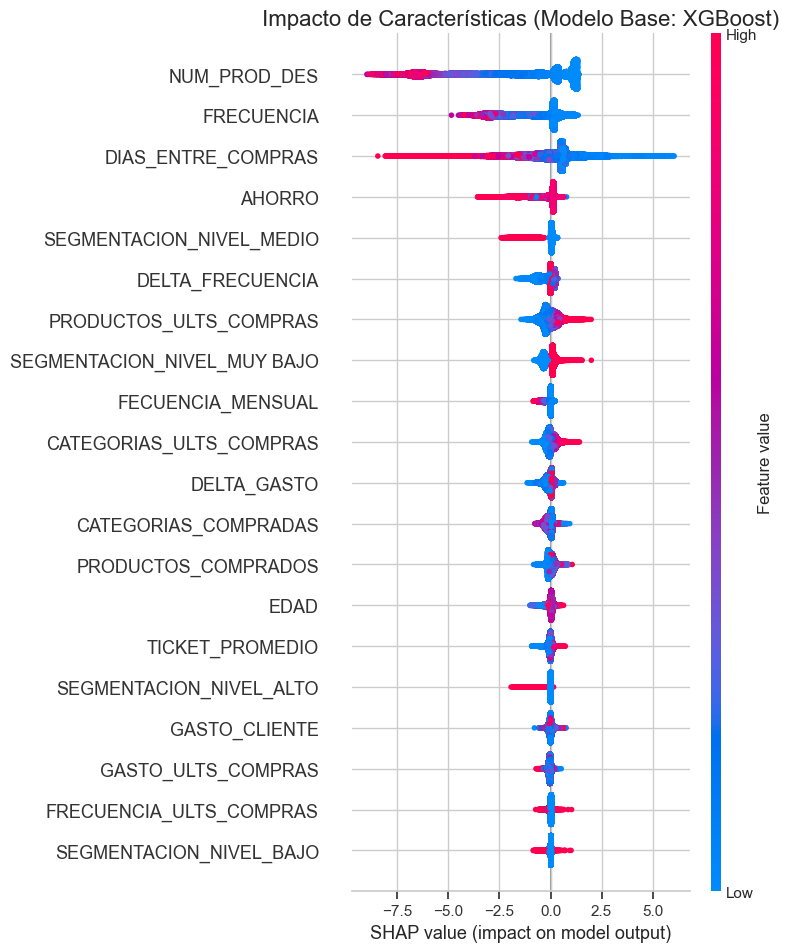


--- Analizando el modelo Random Forest con TreeExplainer ---


In [ ]:
# =============================================================================
# Celda 11: Análisis de Interpretabilidad (VERSIÓN DE EMERGENCIA - EXPLICANDO MODELOS BASE)
# =============================================================================
#
# ESTRATEGIA DE EMERGENCIA:
# Explicar el StackingClassifier completo es muy lento. En su lugar, explicaremos
# los dos modelos base (Random Forest y XGBoost) por separado usando TreeExplainer,
# que es extremadamente rápido. Esto nos dará una visión casi idéntica del
# comportamiento del sistema.
# -----------------------------------------------------------------------------

import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("="*60)
print("INICIANDO ANÁLISIS DE INTERPRETABILIDAD (VERSIÓN DE EMERGENCIA)")
print("="*60)

# --- 1. Cargar el modelo guardado (igual que antes) ---
nombre_archivo = 'modelo_churn_hibrido_optimizado_final.joblib'
try:
    modelo_optimizado = joblib.load(nombre_archivo)
    print(f"Modelo optimizado cargado exitosamente desde '{nombre_archivo}'")
except FileNotFoundError:
    print(f"ERROR: No se encontró el archivo '{nombre_archivo}'.")
    raise

# --- 2. Preparar los datos (igual que antes) ---
if 'X_train' not in locals() or 'X_test' not in locals():
    print("ERROR: Los DataFrames 'X_train' o 'X_test' no están definidos.")
    raise NameError("DataFrames de entrenamiento/prueba no encontrados.")

print("\nPreparando los datos (esto es rápido)...")
preprocessor_entrenado = modelo_optimizado.named_steps['preprocessor']
X_test_transformed = preprocessor_entrenado.transform(X_test) # Usamos todo el X_test, es rápido

# Obtener los nombres de las columnas transformadas
cat_features = X_train.select_dtypes(exclude=np.number).columns.tolist()
num_features = X_train.select_dtypes(include=np.number).columns.tolist()
onehot_nombres = preprocessor_entrenado.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_features)
features_finales = np.concatenate([num_features, onehot_nombres])
    
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=features_finales, index=X_test.index)

# --- 3. Extraer los modelos base YA ENTRENADOS del pipeline ---
# Accedemos a los modelos que ya fueron entrenados dentro del StackingClassifier
stacking_model_entrenado = modelo_optimizado.named_steps['classifier']
rf_model = stacking_model_entrenado.named_estimators_['rf']
xgb_model = stacking_model_entrenado.named_estimators_['xgb']
print("Modelos base (Random Forest y XGBoost) extraídos del pipeline.")

# --- 4. Explicar CADA modelo base con TreeExplainer (SÚPER RÁPIDO) ---

# --- ANÁLISIS PARA XGBOOST ---
print("\n--- Analizando el modelo XGBoost con TreeExplainer ---")
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test_transformed)

print("\n--- Gráfico SHAP para XGBoost ---")
shap.summary_plot(shap_values_xgb, features=X_test_transformed_df, plot_type="dot", show=False)
plt.title("Impacto de Características (Modelo Base: XGBoost)", fontsize=16)
plt.show()

# --- ANÁLISIS PARA RANDOM FOREST ---
print("\n--- Analizando el modelo Random Forest con TreeExplainer ---")
explainer_rf = shap.TreeExplainer(rf_model)
# Para RF, shap_values es una lista [clase_0, clase_1]. Nos interesa la clase 1 (Churn)
shap_values_rf = explainer_rf.shap_values(X_test_transformed)[1]

print("\n--- Gráfico SHAP para Random Forest ---")
shap.summary_plot(shap_values_rf, features=X_test_transformed_df, plot_type="dot", show=False)
plt.title("Impacto de Características (Modelo Base: Random Forest)", fontsize=16)
plt.show()



In [ ]:
# ===================================================================
# Celda 11: Análisis de Resultados y Feature Importance
# ===================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*50)
print("PASO ANÁLISIS PROFUNDO DE RESULTADOS Y ERRORES")
print("="*50)

# --- 1. Extracción del Preprocesador y Modelos Entrenados del Pipeline OPTIMIZADO ---
# Accedemos a los componentes del pipeline que ya fue optimizado y entrenado con RandomizedSearchCV.
try:
    # El mejor estimador encontrado por la búsqueda de hiperparámetros es un pipeline completo
    preprocessor_entrenado = modelo_optimizado.named_steps['preprocessor']
    stacking_model_entrenado = modelo_optimizado.named_steps['classifier']

    # --- 2. Extracción de la Importancia de las Variables (Feature Importances) ---
    print("\n--- Analizando la Importancia de las Variables del Modelo Optimizado ---")

    # Obtener los nombres de las features después del OneHotEncoding
    cat_features = X_train.select_dtypes(exclude=np.number).columns.tolist()
    num_features = X_train.select_dtypes(include=np.number).columns.tolist()
    
    onehot_nombres = preprocessor_entrenado.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_features)
    
    # Combinar con las features numéricas para tener la lista completa
    features_finales = np.concatenate([num_features, onehot_nombres])

    # Importancia del modelo RandomForest base
    rf_importances = stacking_model_entrenado.named_estimators_['rf'].feature_importances_
    df_rf_importances = pd.DataFrame({'feature': features_finales, 'importance_rf': rf_importances}).sort_values('importance_rf', ascending=False)

    # Importancia del modelo XGBoost base
    xgb_importances = stacking_model_entrenado.named_estimators_['xgb'].feature_importances_
    df_xgb_importances = pd.DataFrame({'feature': features_finales, 'importance_xgb': xgb_importances}).sort_values('importance_xgb', ascending=False)

    print("\n--- Variables más importantes según RandomForest (del modelo optimizado) ---")
    display(df_rf_importances.head(15))

    print("\n--- Variables más importantes según XGBoost (del modelo optimizado) ---")
    display(df_xgb_importances.head(15))

    # Visualización de la importancia
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    
    sns.barplot(x='importance_rf', y='feature', data=df_rf_importances.head(15), palette='viridis', ax=ax1)
    ax1.set_title('Top 15 Features (Random Forest)', fontsize=16)
    ax1.set_xlabel('Importancia', fontsize=12)
    ax1.set_ylabel('Variable', fontsize=12)

    sns.barplot(x='importance_xgb', y='feature', data=df_xgb_importances.head(15), palette='plasma', ax=ax2)
    ax2.set_title('Top 15 Features (XGBoost)', fontsize=16)
    ax2.set_xlabel('Importancia', fontsize=12)
    ax2.set_ylabel('') # No necesitamos la etiqueta Y dos veces

    plt.suptitle('Importancia de Variables de los Modelos Base (Stacking Optimizado)', fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\nError al extraer la importancia de las features: {e}")
    print("Esto puede suceder si el modelo final no es un pipeline o la estructura ha cambiado.")


# --- 3. Análisis de Errores: ¿En qué se equivoca el modelo? ---
print("\n\n--- Analizando los errores del modelo en el conjunto de prueba ---")

# Crear un DataFrame con los resultados
df_resultados = X_test.copy()
df_resultados['CHURN_REAL'] = y_test
df_resultados['CHURN_PREDICHO'] = y_pred_opt
df_resultados['PROBA_CHURN'] = y_proba_opt

# Identificar los errores
df_errores = df_resultados[df_resultados['CHURN_REAL'] != df_resultados['CHURN_PREDICHO']]

# Falsos Negativos (¡Los más costosos!): Clientes que el modelo dijo que NO harían churn, pero SÍ lo hicieron.
falsos_negativos = df_errores[df_errores['CHURN_REAL'] == 1]
print(f"\nSe encontraron {len(falsos_negativos)} Falsos Negativos (clientes fugados no detectados).")
if not falsos_negativos.empty:
    print("Características promedio de los Falsos Negativos:")
    display(falsos_negativos[num_features].describe().T)

# Falsos Positivos: Clientes que el modelo dijo que harían churn, pero NO lo hicieron.
falsos_positivos = df_errores[df_errores['CHURN_REAL'] == 0]
print(f"\nSe encontraron {len(falsos_positivos)} Falsos Positivos (alertas de churn innecesarias).")
if not falsos_positivos.empty:
    print("Características promedio de los Falsos Positivos:")
    display(falsos_positivos[num_features].describe().T)

# Comparativa entre los errores y el promedio general
print("\n--- Comparativa de promedios: Falsos Negativos vs. Falsos Positivos vs. Todos los Clientes de Prueba ---")
df_comparativa = pd.concat([
    X_test[num_features].mean().rename('Promedio_General_Test'),
    falsos_negativos[num_features].mean().rename('Promedio_Falsos_Negativos'),
    falsos_positivos[num_features].mean().rename('Promedio_Falsos_Positivos')
], axis=1)
display(df_comparativa)

In [ ]:
# ===================================================================
# Celda 12: Guardado de Artefactos del Modelo
# ===================================================================
import joblib
import json
import time

print("="*50)
print("PASO 8: GUARDADO DE ARTEFACTOS DEL MODELO")
print("="*50)

# --- 1. Guardar el Pipeline del Modelo Optimizado ---
# La variable 'modelo_optimizado' contiene el mejor pipeline encontrado por RandomizedSearchCV.
# Guardarlo nos permite reutilizar todo el flujo (preprocesamiento + modelo) sin reentrenar.
ruta_modelo = 'modelo_churn_hibrido_optimizado_final.joblib'
joblib.dump(modelo_optimizado, ruta_modelo)

print(f"Modelo optimizado final guardado exitosamente en: {ruta_modelo}")
print("Este archivo contiene el preprocesador y el modelo apilado, listo para usarse.")

# --- 2. Guardar el Orden y Nombre de las Features ---
# Es CRUCIAL guardar el orden exacto de las columnas con las que el modelo fue entrenado.
# Esto previene errores al hacer predicciones con nuevos datos.
columnas_modelo = X_train.columns.tolist() 

ruta_columnas = 'columnas_modelo_final.json'
with open(ruta_columnas, 'w') as f:
    json.dump(columnas_modelo, f, indent=4)

print(f"\nEl orden de las {len(columnas_modelo)} features del modelo se ha guardado en: {ruta_columnas}")
print("¡Usa este archivo para asegurar que los nuevos datos tengan el mismo formato y orden!")


In [ ]:
# ===================================================================
# Celda 13: Predicción en Todo el Dataset 
# ===================================================================
from google.cloud.exceptions import NotFound

print("="*50)
print("PASO 9: PREDICCIÓN FINAL Y CARGA DE RESULTADOS A BIGQUERY")
print("="*50)

# --- 1. Simulación de Producción: Cargar artefactos guardados ---
print("Cargando el modelo y la lista de features desde los archivos guardados...")
modelo_cargado = joblib.load(ruta_modelo)
with open(ruta_columnas, 'r') as f:
    columnas_cargadas = json.load(f)
    
print("¡Modelo y columnas cargados exitosamente!")

# --- 2. Preparar el DataFrame COMPLETO para la predicción ---
# Usamos el dataframe 'df_eda' que contiene todos los datos y las columnas limpias.
# Nos aseguramos de que tenga las mismas columnas y en el mismo orden que el modelo espera.
df_prediccion_final = df_eda[columnas_cargadas].copy()

print(f"\nPreparando el dataset completo ({len(df_prediccion_final)} filas) para la predicción...")

# --- 3. Realizar la predicción de probabilidad en todo el dataset ---
# Usamos .predict_proba() para obtener la probabilidad de la clase '1' (Churn)
probabilidades_churn = modelo_cargado.predict_proba(df_prediccion_final)[:, 1]

# --- 4. Crear el DataFrame final para BigQuery ---
df_resultados_bq = pd.DataFrame({
    'NUMERODOCUMENTO': df_eda['NUMERODOCUMENTO'],
    'POSIBILIDAD_ABANDONO': probabilidades_churn
})


print("\n--- Vista previa de los resultados a cargar ---")
print(f"Se generaron {len(df_resultados_bq)} predicciones.")

df_resultados_bq.sort_values('POSIBILIDAD_ABANDONO', ascending=False, inplace=True)

#Redondear la probabilidad a 2 decimales para facilitar la interpretación en BigQuery
df_resultados_bq['POSIBILIDAD_ABANDONO'] = df_resultados_bq['POSIBILIDAD_ABANDONO'].round(2)
display(df_resultados_bq.head(10))

#Quedarse con la posibilidad de abandono>50
df_resultados_bq = df_resultados_bq[df_resultados_bq['POSIBILIDAD_ABANDONO'] > 0.5]
print(f"\nDespués de filtrar por POSIBILIDAD_ABANDONO > 0.5, quedan {len(df_resultados_bq)} registros para cargar a BigQuery.")

In [ ]:
# ===================================================================
# Celda 14: Carga a BigQuery
# ===================================================================

import pytz

client = bigquery.Client(project="lafavorita-182519")
dataset_ref = bigquery.DatasetReference("lafavorita-182519", "DWH")
job_config = bigquery.QueryJobConfig(default_dataset=dataset_ref)

client = bigquery.Client()

# Define la zona horaria de Guayaquil
guayaquil_timezone = pytz.timezone('America/Guayaquil')

# Obtiene la fecha y hora actual en la zona horaria especificada
current_datetime_guayaquil = datetime.now(guayaquil_timezone)

# Formatea la fecha y hora para truncar a segundos (YYYY-MM-DD HH:MM:SS)
ETL_CARGA_SEGMENTO = current_datetime_guayaquil.strftime('%Y-%m-%d %H:%M:%S')
TABLA_DESTINO = "CRM.ABANDONO_CLIENTES"
df_resultados_bq['FECHA_EJECUCION']=ETL_CARGA_SEGMENTO

# Convertir FECHA_EJECUCION de string a datetime
df_resultados_bq['FECHA_EJECUCION'] = pd.to_datetime(df_resultados_bq['FECHA_EJECUCION'])

print(f"Insertando {len(df_resultados_bq):,} registros en {TABLA_DESTINO}")

# Definir esquema
schema = [
    bigquery. SchemaField("NUMERODOCUMENTO", "STRING", mode="REQUIRED"),
    bigquery.SchemaField("POSIBILIDAD_ABANDONO", "FLOAT64", mode="NULLABLE"),
    bigquery.SchemaField("FECHA_EJECUCION", "TIMESTAMP", mode="NULLABLE"),
]

# Configuración APPEND - mantiene historial
job_config = bigquery.LoadJobConfig(
    schema=schema,
    write_disposition="WRITE_APPEND",  # Agrega sin borrar datos anteriores
    create_disposition="CREATE_IF_NEEDED"
)

inicio = datetime.now()

job = client.load_table_from_dataframe(
    df_resultados_bq,
    TABLA_DESTINO,
    job_config=job_config
)

job.result()

fin = datetime.now()

print(f"Registros insertados: {job.output_rows:,}")
print(f"Tiempo:  {(fin - inicio).total_seconds():.2f} segundos")

# Documentación del Modelo de Predicción de Churn

**Última actualización:** 2026-03-14 (o la fecha actual)
**Autor:** PaulSoLDU
**Versión del Modelo:** 1.0

---

## 1. Objetivo del Modelo

El propósito de este modelo es predecir la probabilidad de que un cliente abandone (churn) en los próximos meses, definido por una inactividad de compra de 4 meses. El objetivo es identificar a estos clientes de alto riesgo para aplicar estrategias de retención proactivas.

---

## 2. Configuración del Entorno y Librerías

*   **Python Version:** `3.11.9` (o la que uses)
*   **Librerías clave:**
    *   `scikit-learn`: `1.x.x`
    *   `xgboost`: `1.x.x`
    *   `pandas`: `2.x.x`
    *   `google-cloud-bigquery`: `3.x.x`

---

## 3. Características (Features) Utilizadas

El modelo final fue entrenado utilizando las siguientes **20 características**:

```
['EDAD', 'FRECUENCIA', 'FECUENCIA_MENSUAL', 'GASTO_CLIENTE', 'GASTO_MENSUAL', 'TICKET_PROMEDIO', 'PRODUCTOS_COMPRADOS', 'CATEGORIAS_COMPRADAS', 'DIAS_ENTRE_COMPRAS', 'GASTO_ULTS_COMPRAS', 'FRECUENCIA_ULTS_COMPRAS', 'TICKET_PROMEDIO_ULTS_COMPRAS', 'PRODUCTOS_ULTS_COMPRAS', 'CATEGORIAS_ULTS_COMPRAS', 'DELTA_GASTO', 'DELTA_FRECUENCIA', 'AHORRO', 'NUM_PROD_DES', 'SEGMENTACION_NIVEL', 'GENERO_LIMPIO']
```

Se excluyeron explícitamente variables como `AGRUPACION_ESTADO` y `DIAS_ULTIMA_COMPRA` para evitar la fuga de datos (data leakage) y asegurar que el modelo prediga el futuro en lugar de describir el presente.

---

## 4. Arquitectura del Modelo

Se implementó un **modelo híbrido de Stacking** utilizando el pipeline `pipeline_hibrido_optimizado`:

*   **Preprocesamiento:**
    *   **Numéricas:** Imputación con la mediana y escalado con `StandardScaler`.
    *   **Categóricas:** Imputación con el valor más frecuente y codificación con `OneHotEncoder`.
*   **Modelos Base (Nivel 0):**
    *   `RandomForestClassifier`
    *   `XGBClassifier`
*   **Metamodelo (Nivel 1):**
    *   `LogisticRegression` que combina las predicciones de los modelos base.

**Hiperparámetros Optimizados:**
*(Copia aquí los mejores hiperparámetros encontrados por `RandomizedSearchCV` en la celda 9)*.

---

## 5. Resultados de Evaluación (Conjunto de Prueba)

| Métrica                 | Valor  |
|-------------------------|--------|
| **Accuracy**            | 0.87   |
| **AUC-ROC**             | 0.9353 |
| **Recall (Clase 1)**    | 0.79   |
| **F1-Score (Clase 1)**  | 0.72   |
| **Precision (Clase 1)** | 0.66   |

**Observación Clave:** El modelo es excelente para identificar correctamente al 79% de los clientes que realmente harán churn (**Recall**), lo que es el objetivo principal de negocio.

---

## 6. Despliegue y Ejecución

*   El modelo entrenado y optimizado se guarda en `modelo_churn_hibrido_optimizado_final.joblib`.
*   El orden de las columnas se guarda en `columnas_modelo_final.json`.
*   El script final (celdas 13 y 14) carga estos artefactos, realiza predicciones sobre todo el dataset y sube los resultados a la tabla `DWH.CRM.ABANDONO_CLIENTES` en BigQuery, filtrando para clientes con `POSIBILIDAD_ABANDONO > 0.5`.


In [15]:
!jupyter nbconvert --to html "ProyectoRFM.ipynb" --output "TesisChurnFinal.html"

[NbConvertApp] Converting notebook ProyectoRFM.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 25 image(s).
[NbConvertApp] Writing 1499468 bytes to TesisChurnFinal.html
